# Motion tuning

This notebook generates the plots for Figure 4. All plots use the retinal model trained for prediction. The pre-trained model can either be downloaded from this repo or can be trained from scatch (see README).

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import torch
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from retina import train, analysis

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
root = os.path.expanduser("~/PycharmProjects/RetinalModel")

In [4]:
model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_128_8")

In [5]:
torch.manual_seed(0)
grating_query = analysis.GratingQuery(root, model, ablate_recurrence=False)

## OS and DS units

### Orientation and Direction selectivity

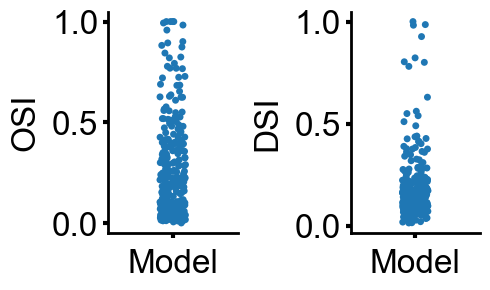

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(5, 3))

def plot_XS_units(xlabel, ylabel, ax):
    np.random.seed(42)  # to get same results in stripplot 
    sns.stripplot(pd.DataFrame({xlabel: grating_query.filtered_tuning_results[ylabel]}), ax=ax)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    labelsize = 24
    ax.xaxis.set_tick_params(width=3, labelsize=labelsize, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=labelsize)
    ax.set_ylabel(ylabel, fontsize=labelsize, labelpad=8)
    
plot_XS_units("Model", "OSI", axs[0])
plot_XS_units("Model", "DSI", axs[1])
fig.tight_layout()
plt.savefig(f"{root}/figures/fig4/OSI_DSI.svg", format="svg", transparent=False, bbox_inches="tight")

### Orientation preference

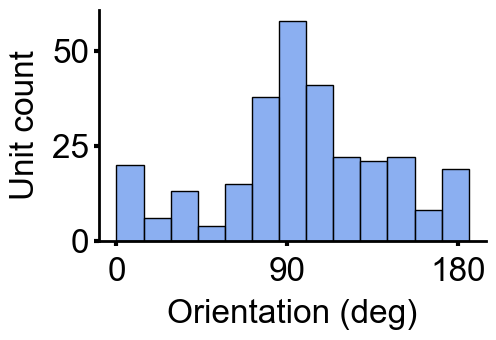

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
sns.histplot(pd.DataFrame({"x": grating_query.filtered_tuning_results["theta"] % np.pi}), x="x", bins="auto", legend=False, color="cornflowerblue", ax=ax)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)
labelsize = 24
ax.xaxis.set_tick_params(width=3, labelsize=labelsize, pad=8)
ax.yaxis.set_tick_params(width=3, labelsize=labelsize)
ax.set_xlabel("Orientation (deg)", fontsize=labelsize, labelpad=8)
ax.set_ylabel("Unit count", fontsize=labelsize, labelpad=8)
ax.set_xticks([0, 1.5, 3.0])
ax.set_xticklabels(["0", "90", "180"])
plt.savefig(f"{root}/figures/fig4/orientation_dist.svg", format="svg", transparent=False, bbox_inches="tight")

### Polar plot of orientation and direction selective units 

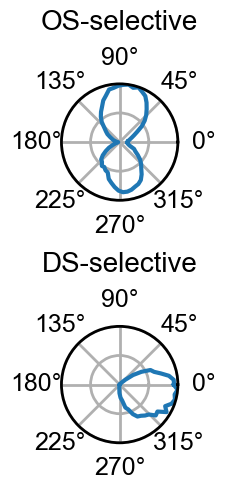

In [8]:
fig, axs = plt.subplots(2, 1, subplot_kw={"projection": "polar"}, figsize=(3, 5))

def plot_orientation_tuning(unit_idx, title, ax):
    theta, tuning_curve = grating_query.query.orientation_tuning_curve(unit_idx)
    ax.plot(theta, tuning_curve/tuning_curve.max(), linewidth=3)
    ax.set_rmax(1)
    ax.grid(linewidth=2)
    ax.spines["polar"].set_linewidth(2)
    ax.set_yticklabels([])
    labelsize = 18
    ax.xaxis.set_tick_params(width=3, labelsize=labelsize, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=13)
    ax.set_title(title, fontsize=20, pad=12)
    
plot_orientation_tuning(25, "OS-selective", axs[0])
plot_orientation_tuning(153, "DS-selective", axs[1])
plt.tight_layout()
plt.savefig(f"{root}/figures/fig4/orientation_tuning_curves.svg", format="svg", transparent=False, bbox_inches="tight")

In [9]:
print("Standard model")
#grating_query = analysis.GratingQuery(root, model, ablate_recurrence=False)
osi = grating_query.filtered_tuning_results["OSI"]
dsi = grating_query.filtered_tuning_results["DSI"]
print(f"Responsive units={grating_query.all_tuning_results.shape[0]}")
print(f"% units orientation selective={(osi[osi>0.5].shape[0]/287)*100}")
print(f"% units direction selective={(dsi[dsi>0.5].shape[0]/287)*100}")

print("Model with ablated recurrency")
grating_query_ablated = analysis.GratingQuery(root, model, ablate_recurrence=True)
osi = grating_query_ablated.filtered_tuning_results["OSI"]
dsi = grating_query_ablated.filtered_tuning_results["DSI"]
print(f"Responsive units={grating_query_ablated.all_tuning_results.shape[0]}")
print(f"% units orientation selective={(osi[osi>0.5].shape[0]/287)*100}")
print(f"% units direction selective={(dsi[dsi>0.5].shape[0]/287)*100}")

Standard model
Responsive units=287
% units orientation selective=16.376306620209057
% units direction selective=4.529616724738676
Model with ablated recurrency
Responsive units=287
% units orientation selective=17.421602787456447
% units direction selective=4.181184668989547


## Texture selectivity

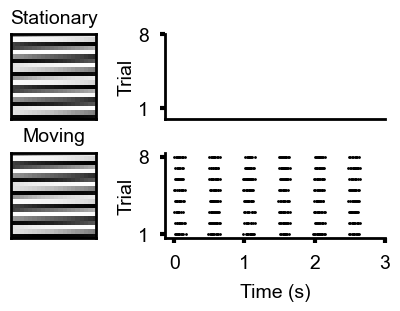

In [10]:
torch.manual_seed(0)
#grating_query = analysis.GratingQuery(root, model, ablate_recurrence=False)
texture_motion = analysis.TextureMotion(model, grating_query, 241, sf=0.3, ablate_recurrence=False) # 247 or 15 # , sf=0.25
#241
fig = plt.figure(constrained_layout=True, figsize=(4, 3))
spec = gridspec.GridSpec(ncols=6, nrows=2, figure=fig)
ax1 = fig.add_subplot(spec[0, :2])
ax2 = fig.add_subplot(spec[0, 2:])
ax3 = fig.add_subplot(spec[1, :2])
ax4 = fig.add_subplot(spec[1, 2:])

def plot_grating_and_raster(title, grating, raster_x, raster_y, ax_grating, ax_raster, probe_ms=3000):
    ax_grating.imshow(grating, cmap="Greys", vmin=-1, vmax=1)
    ax_raster.scatter(raster_x, raster_y+1, s=1, c="black")
    ax_grating.set_title(title, fontsize=14, pad=8)
    ax_grating.set_xticks([])
    ax_grating.set_yticks([])
    ax_grating.spines["top"].set_linewidth(2)
    ax_grating.spines["bottom"].set_linewidth(2)
    ax_grating.spines["left"].set_linewidth(2)
    ax_grating.spines["right"].set_linewidth(2)
    
    ax_raster.spines["top"].set_visible(False)
    ax_raster.spines["right"].set_visible(False)
    ax_raster.spines["bottom"].set_linewidth(2)
    ax_raster.spines["left"].set_linewidth(2)
    ax_raster.xaxis.set_tick_params(width=3, labelsize=14, pad=8)
    ax_raster.yaxis.set_tick_params(width=3, labelsize=14, pad=8)
    ax_raster.set_yticks([1, 8])
    ax_raster.set_xticks([0, 240, 480, 720])
    ax_raster.set_xticklabels([0, 1, 2, 3])
    ax_raster.set_xlabel("Time (s)", fontsize=14, labelpad=8)
    ax_raster.set_ylabel("Trial", fontsize=14, labelpad=2)
    
plot_grating_and_raster("Stationary", texture_motion.fixed_grating[0], *texture_motion.fixed_raster, ax1, ax2)
ax2.set_xticks([])
ax2.set_xlabel("")
plot_grating_and_raster("Moving", texture_motion.optimal_grating[0], *texture_motion.optimal_raster, ax3, ax4)
plt.savefig(f"{root}/figures/fig4/texture_selectivity_raster.svg", format="svg", transparent=False, bbox_inches="tight")

In [11]:
print("Standard model")
#torch.manual_seed(0)
#grating_query = analysis.GratingQuery(root, model, ablate_recurrence=False)#
#texture_motion = analysis.TextureMotion(model, grating_query, 241, sf=0.3, ablate_recurrence=False)
n_textured_tuned_units = texture_motion.count_texture_tuned_units(model, grating_query)
print(f"% units texture tuned={(n_textured_tuned_units/287)*100}")

print("Model with ablated recurrency")
torch.manual_seed(0)
grating_query_ablate = analysis.GratingQuery(root, model, ablate_recurrence=True)
texture_motion_ablate = analysis.TextureMotion(model, grating_query_ablate, 241, sf=0.3, ablate_recurrence=True)
n_textured_tuned_units_ablate = texture_motion_ablate.count_texture_tuned_units(model, grating_query_ablate)
print(f"% units texture tuned={(n_textured_tuned_units_ablate/287)*100}")

Standard model
% units texture tuned=9.059233449477352
Model with ablated recurrency
% units texture tuned=8.362369337979095


## Object motion selectivity

In [12]:
torch.manual_seed(24)
unit_idx=13
differential_motion = analysis.DifferentialMotion(model, unit_idx=unit_idx, theta=np.pi, spatial_freq=0.06, temporal_freq=2, y0=10, x0=13, r=3, lum=0.5)

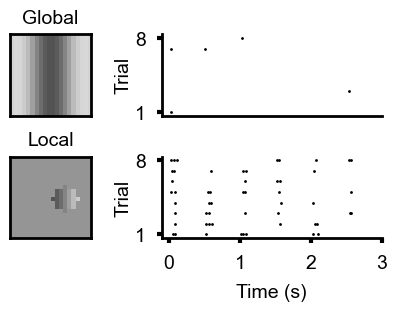

In [13]:
fig = plt.figure(constrained_layout=True, figsize=(4, 3))
spec = gridspec.GridSpec(ncols=6, nrows=2, figure=fig)
ax1 = fig.add_subplot(spec[0, :2])
ax2 = fig.add_subplot(spec[0, 2:]) 
ax3 = fig.add_subplot(spec[1, :2])
ax4 = fig.add_subplot(spec[1, 2:])

plot_grating_and_raster("Global", differential_motion.grating[420-40], *differential_motion.global_raster, ax1, ax2)
ax2.set_xticks([])
ax2.set_xlabel("")
plot_grating_and_raster("Local", differential_motion.masked_grating[420-40], *differential_motion.local_raster, ax3, ax4)
plt.savefig(f"{root}/figures/fig4/motion_selectivity_raster.svg", format="svg", transparent=False, bbox_inches="tight")

In [14]:
torch.manual_seed(0)
rf_query = analysis.RFQuery(root, model)

INFO:util:Processing batch 0 out of 4...
INFO:util:Processing batch 1 out of 4...
INFO:util:Processing batch 2 out of 4...
INFO:util:Processing batch 3 out of 4...
INFO:gaussian:CC criteria exclusion 219
INFO:gaussian:Location criteria exclusion 38
INFO:gaussian:Envelope criteria exclusion 12


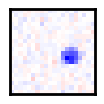

In [15]:
rf = rf_query.rfs[unit_idx]

fig, ax = plt.subplots(1, 1, figsize=(1.1, 1.1))
ax.imshow(rf, vmin=-rf.abs().max(), vmax=rf.abs().max(), cmap="bwr")
ax.set_xticks([])
ax.set_yticks([])
ax.spines["top"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.spines["right"].set_linewidth(2)

## Anticipation response

In [16]:
torch.manual_seed(0)
ant = analysis.anticipation.AnticipationAnalysis(model, bar_width=3, bar_x0=11, luminance=0,
                                                 ablate_recurrence=False, bar_speed=8,smooth=True)

In [17]:
sal_impulse_df = analysis.load_anticipation_df(root, "sal_a.csv")
sal_moving_df = analysis.load_anticipation_df(root, "sal_b.csv")

rabbit_impulse_df = analysis.load_anticipation_df(root, "rabbit_a.csv")
rabbit_moving_df = analysis.load_anticipation_df(root, "rabbit_b.csv")

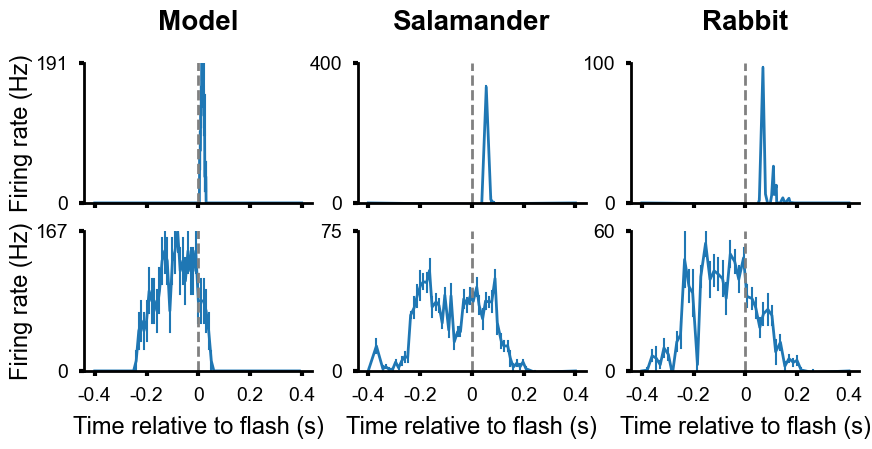

In [18]:
fig, axs = plt.subplots(2, 3, sharex=True, figsize=(10, 4))

def plot_anticipation_fr(data, upper, title, ax):
    sns.lineplot(data, x="t", y="r", errorbar="se", err_style="bars", linewidth=2, ax=ax)
    if upper < 1:
        ax.plot([0, 0], [0, 1], "--", c="Grey", linewidth=2)
    else:
        ax.plot([0, 0], [0, upper], "--", c="Grey", linewidth=2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    ax.xaxis.set_tick_params(width=3, labelsize=14, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=14, pad=8)
    ax.set_xticks([-400, -200, 0, 200, 400])
    ax.set_xticklabels([-0.4, -0.2, 0, 0.2, 0.4])
    
    if upper < 1:
        ax.set_ylim([0, upper])
        ax.set_yticks([0, upper])
        ax.set_yticklabels([0, int(upper * 239)])
    else:
        ax.set_ylim([0, upper])
        ax.set_yticks([0, upper])
        ax.set_yticklabels([0, upper])
    
    fs = 17
    ax.set_ylabel("Firing rate (Hz)", fontsize=fs, labelpad=2)
    ax.set_xlabel("Time relative to flash (s)", fontsize=fs, labelpad=8)
    ax.set_title(title, fontsize=20, pad=24, weight="bold")
    
neuron_idx = 192
plot_anticipation_fr(ant.flash_bar_spikes_df(neuron_idx), 0.8, "Model", axs[0, 0])
plot_anticipation_fr(ant.right_moving_bar_spikes_df(neuron_idx), 0.7, "", axs[1, 0])

plot_anticipation_fr(sal_impulse_df, 400, "Salamander", axs[0, 1])
plot_anticipation_fr(sal_moving_df, 75, "", axs[1, 1])
axs[0, 1].set_ylabel("")
axs[1, 1].set_ylabel("")

plot_anticipation_fr(rabbit_impulse_df, 100, "Rabbit", axs[0, 2])
plot_anticipation_fr(rabbit_moving_df, 60, "", axs[1, 2])
axs[0, 2].set_ylabel("")
axs[1, 2].set_ylabel("")

plt.savefig(f"{root}/figures/fig4/anticipation.svg", format="svg", transparent=False, bbox_inches="tight")